# Sphere Simulation

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from geomstats.geometry.hypersphere import Hypersphere
import geomstats.visualization as visualization

INFO: Using numpy backend


In [2]:
plt.rcParams.update({'font.size': 10,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})

## Setting up

In [3]:
sphere = Hypersphere(dim=2)

mean1 = np.array([0., 0., 1.])
mean2 = -mean1
tau2 = 0.25

n = 2000
sigma2 = 0.75

def sample_G(n_samples): 
    classes = np.random.randint(0,2,n_samples).reshape(-1,1)
    samples1 = sphere.random_riemannian_normal(mean1, 1./tau2, n_samples)
    samples2 = sphere.random_riemannian_normal(mean2, 1./tau2, n_samples)
    return classes*samples1 + (1-classes)*samples2

def extrinsic_to_latlon(x):
    theta, phi = sphere.extrinsic_to_spherical(x).T
    lat = np.pi/2 - theta
    lon = phi - np.pi
    return lon, lat

In [4]:
Theta = sample_G(n)
Theta_lon, Theta_lat = extrinsic_to_latlon(Theta)

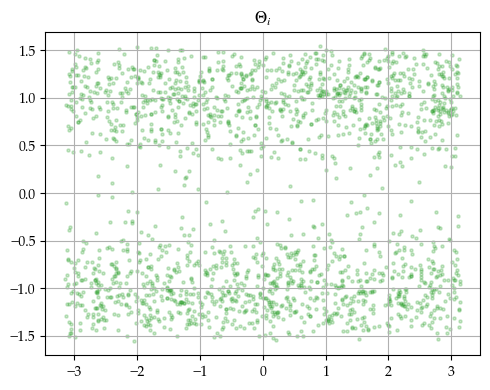

In [5]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111)

ax.grid(True)
ax.set_title('$\\Theta_i$')
ax.scatter(Theta_lon, Theta_lat, color='C2', s=5, alpha=0.25)

plt.tight_layout()

In [6]:
X = sphere.random_riemannian_normal(Theta, 1./sigma2, n)
X_lon, X_lat = extrinsic_to_latlon(X)

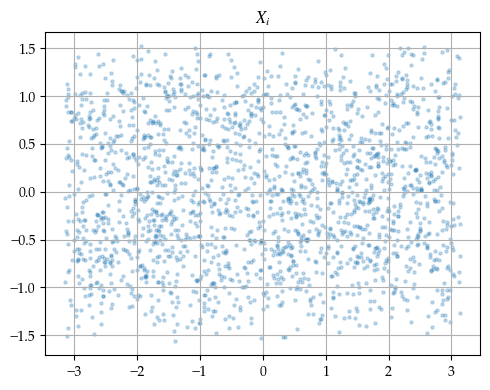

In [7]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111)

ax.grid(True)
ax.set_title('$X_i$')
ax.scatter(X_lon, X_lat, color='C0', s=5, alpha=0.25)

plt.tight_layout()

## Density estimation

In [8]:
def density_estimate(X_, M):
    out = np.zeros(shape=X_.shape[0])
    for i in range(X.shape[0]):
        for m in range(M):
            p_m = sp.special.legendre(m)
            dot = X_ @ X[i,:]
            out += (2*m+1)*p_m(dot)/(4*np.pi)        
    return out/X.shape[0]

In [25]:
M = 2
res_lon = 40
res_lat = 60

x_lon = np.linspace(-np.pi, np.pi, res_lon)
x_lat = np.linspace(-np.pi/2., np.pi/2, res_lat)
x_lon_, x_lat_ = np.meshgrid(x_lon, x_lat)

theta = np.pi/2 - x_lat_.ravel()
phi = x_lon_.ravel()

X_ = sphere.spherical_to_extrinsic(np.stack([theta, phi], axis=-1))

hat_f = density_estimate(X_, M).reshape(res_lat, res_lon)

Text(0.5, 1.0, '$\\hat{f}(\\cdot)$')

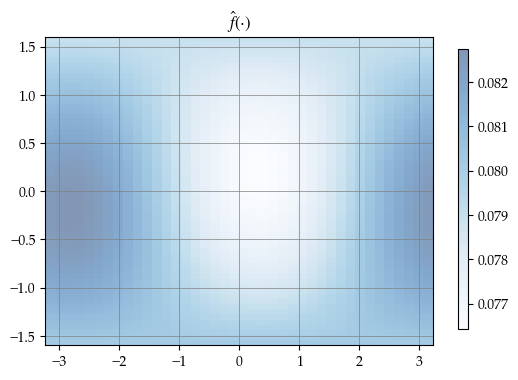

In [26]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111)

im = ax.pcolormesh(
    x_lon_,
    x_lat_,
    hat_f,
    # hat_f_alt,
    alpha=0.5,
    shading='auto',
    cmap='Blues'
)

ax.grid(True, color='gray', lw=0.5)
cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
fig.colorbar(im, orientation='vertical', cax=cbar_ax)
ax.set_title('$\\hat{f}(\cdot)$')

## Empirical Bayes denoising

In [27]:
def denoiser(X_, M, rho):
    
    # estimate f
    hat_f = density_estimate(X_, M)
    
    # estimate grad f
    hat_grad_f = np.zeros(shape=(X_.shape[0],3))
    theta = np.pi/2 - x_lat      # colatitude
    phi = x_lon                  # longitude
    for i in range(X.shape[0]):
        for m in range(1,M):
            p_m_deriv = sp.special.legendre(m).deriv()
            dot = X_ @ X[i,:]
            hat_grad_f += (2*m+1)*np.outer(p_m_deriv(dot), X[i,:])/(4*np.pi)
    hat_grad_f = hat_grad_f/X.shape[0]
           
    # compute score function
    hat_score = hat_grad_f / np.maximum(hat_f, rho).reshape(-1,1)

    
    # good up to this point already
    
    
    # compute denoiser
    delta = np.zeros((X_.shape[0],3))
    for j in range(X_.shape[0]):
        x_ = X_[j,:].reshape(-1,1)
        v = X_[j,:] + (np.eye(3) - x_@ x_.T)@hat_score[j,:]
        delta[j,:] = sphere.metric.exp(sigma2*v, X_[j,:])
    
    return delta

In [28]:
rho = 0.01
delta = denoiser(X, M, rho)
delta_lon, delta_lat = extrinsic_to_latlon(delta)

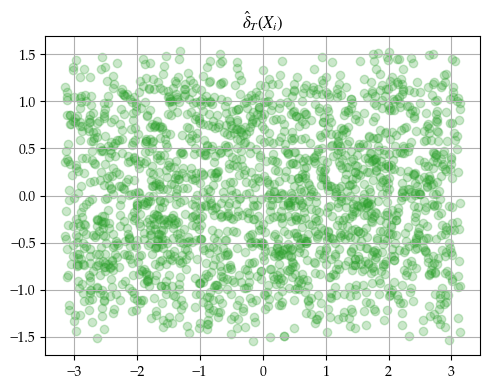

In [29]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111)

ax.grid(True)
ax.set_title('$\\hat{\\delta}_T(X_i)$')
ax.scatter(delta_lon, delta_lat, color='C2', alpha=0.25)

plt.tight_layout()

## Plotting

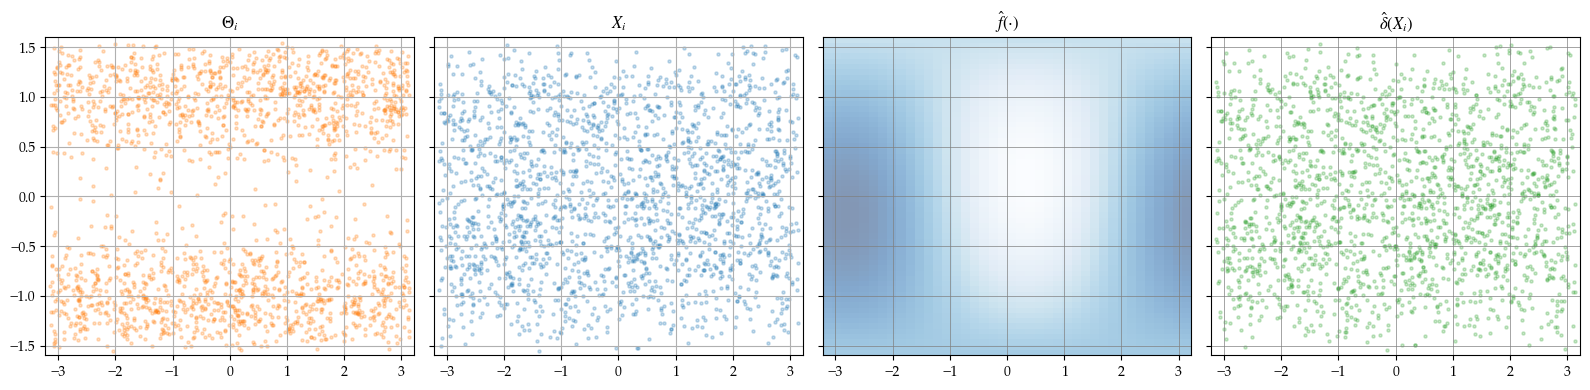

In [30]:
fig, ax = plt.subplots(1, 4, figsize=(16,4), sharex=True, sharey=True)

ax[0].grid(True)
ax[0].set_title('$\\Theta_i$')
ax[0].scatter(Theta_lon, Theta_lat, color='C1', s=5, alpha=0.25)

ax[1].grid(True)
ax[1].set_title('$X_i$')
ax[1].scatter(X_lon, X_lat, color='C0', s=5, alpha=0.25)

im = ax[2].pcolormesh(
    x_lon_,
    x_lat_,
    hat_f,
    alpha=0.5,
    shading='auto',
    cmap='Blues'
)
ax[2].grid(True, color='gray', lw=0.5)
ax[2].set_title('$\\hat{f}(\cdot)$')

ax[3].grid(True, color='gray', lw=0.5)
ax[3].scatter(delta_lon, delta_lat, color='C2', s=5, alpha=0.25)
ax[3].set_title('$\\hat{\\delta}(X_i)$')

plt.tight_layout()

# plt.savefig('astro.pdf')

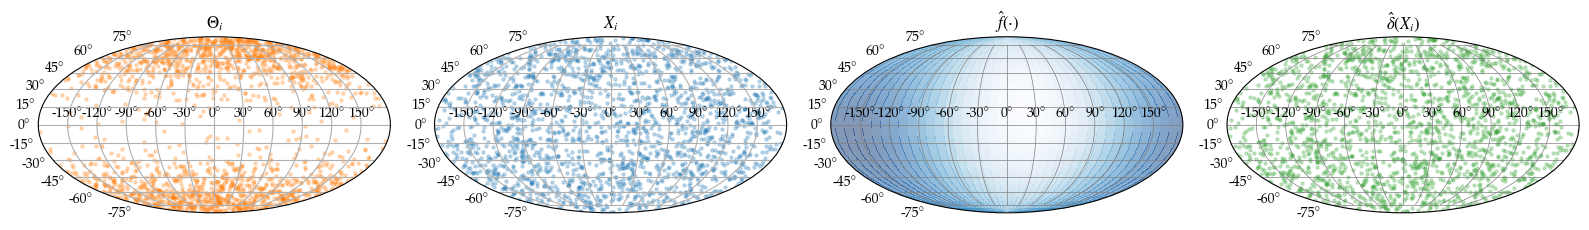

In [31]:
fig = plt.figure(figsize=(16,4))
ax = [None] * 4

ax[0] = fig.add_subplot(141, projection='mollweide')
ax[0].grid(True)
ax[0].set_title('$\\Theta_i$')
ax[0].scatter(Theta_lon, Theta_lat, color='C1', s=5, alpha=0.25)

ax[1] = fig.add_subplot(142, projection='mollweide')
ax[1].grid(True)
ax[1].set_title('$X_i$')
ax[1].scatter(X_lon, X_lat, color='C0', s=5, alpha=0.25)

ax[2] = fig.add_subplot(143, projection='mollweide')
im = ax[2].pcolormesh(
    x_lon_,
    x_lat_,
    hat_f,
    alpha=0.5,
    shading='auto',
    cmap='Blues'
)
ax[2].grid(True, color='gray', lw=0.5)
ax[2].set_title('$\\hat{f}(\cdot)$')

ax[3] = fig.add_subplot(144, projection='mollweide')
ax[3].grid(True, color='gray', lw=0.5)
ax[3].scatter(delta_lon, delta_lat, color='C2', s=5, alpha=0.25)
ax[3].set_title('$\\hat{\\delta}(X_i)$')

plt.tight_layout()

# plt.savefig('astro.pdf')
